![imagen](img/python.jpg)

# Streamlit con APIs y Machine Learning

Creemos un proyecto en el que utilicemos Streamlit para la interfaz de usuario.

Además, utilizaremos API y aprendizaje automático (ML), de modo que tendremos una aplicación capaz de realizar predicciones basadas en los datos recibidos de un servicio API.



## API

Regístrate aquí:

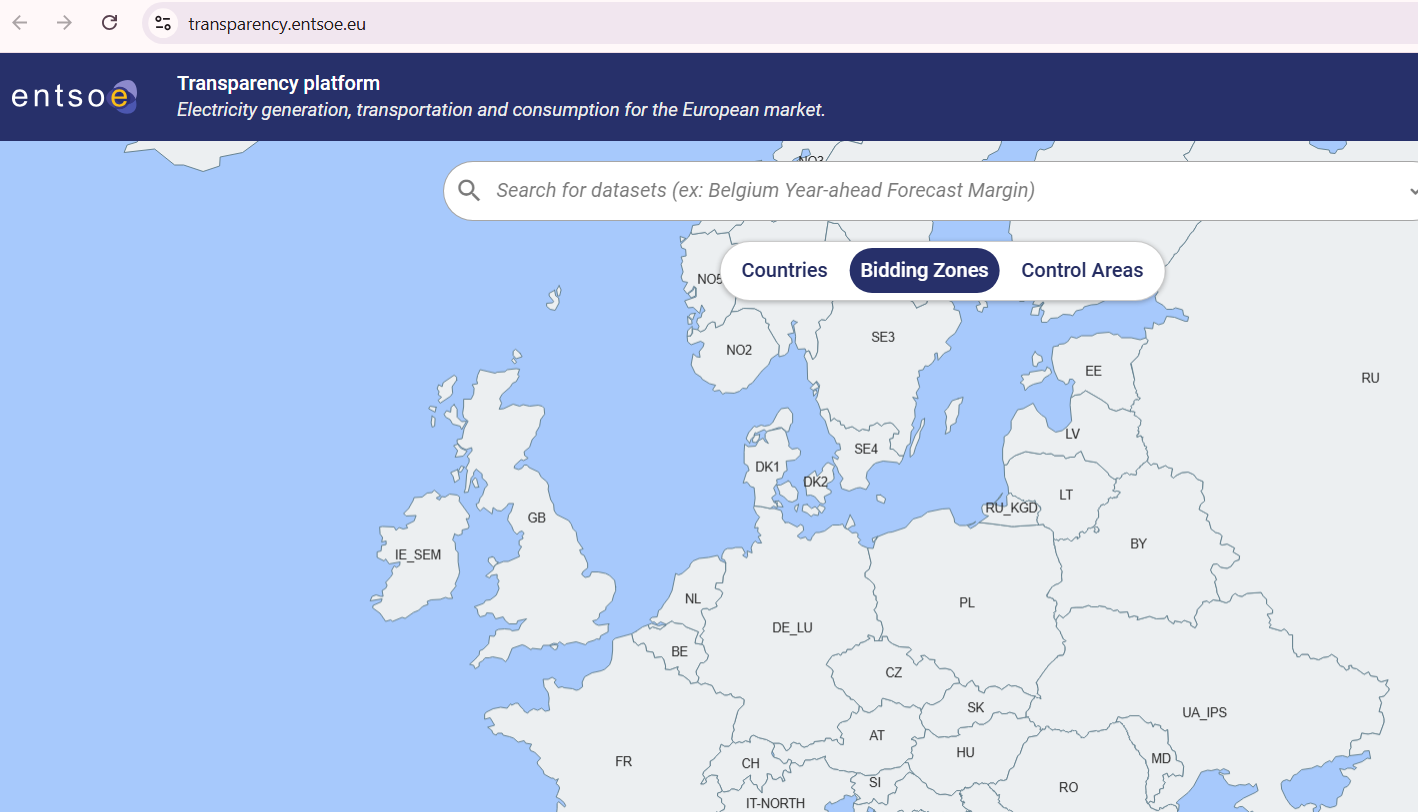

In [ ]:
# https://transparency.entsoe.eu/

# This website will give us data about energy. It's free, we only need to register

# Register on the platform

# Send an email to transparency@entsoe.eu with “Restful API access” in the subject line.
# Indicate the email address you entered during registration in the email body.
# The ENTSO-E Helpdesk will make their best efforts to respond to your request within 3 working days.
# They will normally respond next working day, 3 days is to be on the safe side.
# When you receive answer from them, there will be a button on your "My account settings" page.

# Example of email

# To --> transparency@entsoe.eu
# Subject--> Restful API access

# Dear team,

# My email is my_email@blablabla.xx

# I would like to have an API key to practise and learn digital skills.

# Thank you very much for your help.
# Best regards,

# Alberto

# when they respond, you will have your API key

# Click it to generate API token.

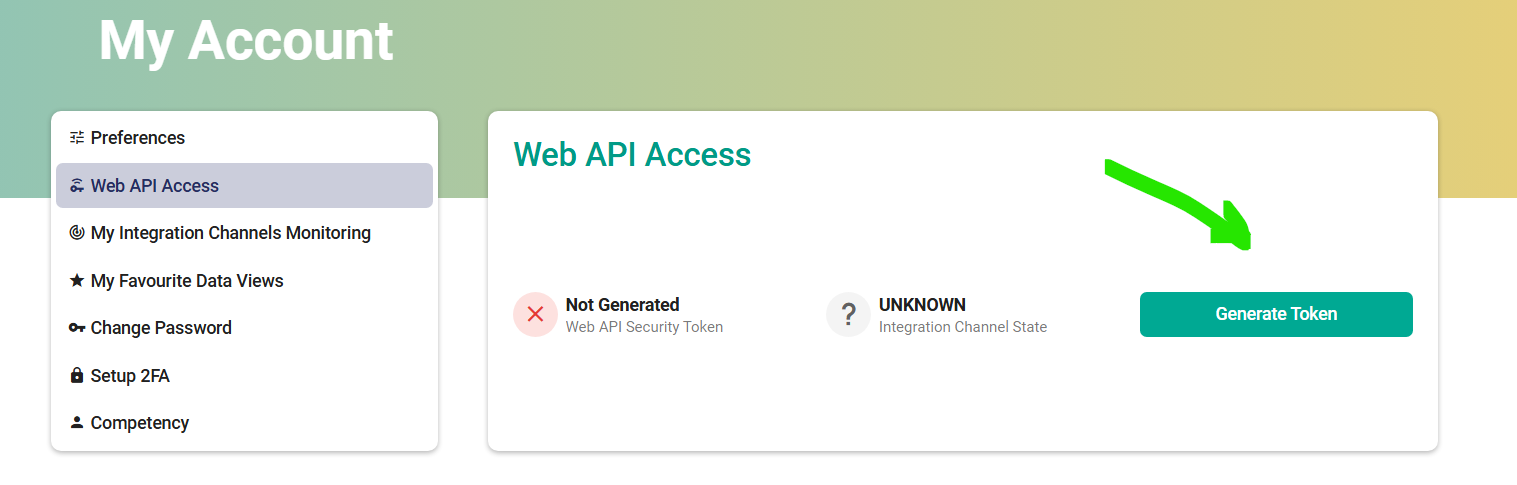

Añadimos `.env` a `.gitignore`, para que Git ignore ese archivo (donde se encontrará la clave API de Entsoe).

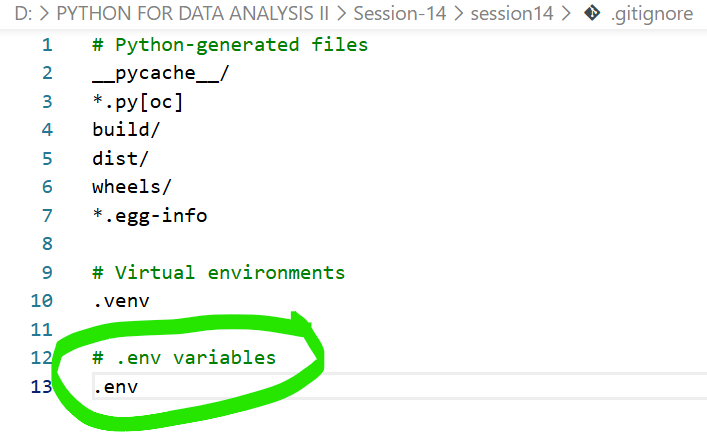

Ahora tendremos `.env` y `.env.example` (este último con una plantilla para `.env`).

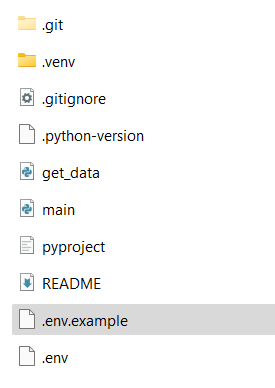

Y el archivo `.env.example`:

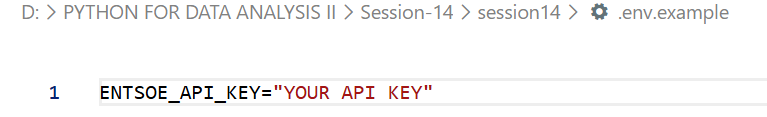

Ahora vamos a crear el proyecto con **uv** y a crear y activar el entorno virtual (`.venv`)

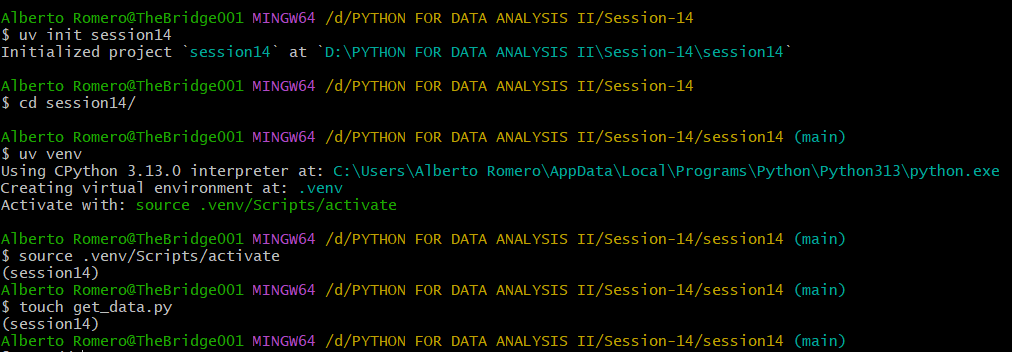

Escribe un script de Python llamado `get_data.py` para recuperar los datos de la API.

```python

"""
This script retrieves electricity data from the ENTSO-E Transparency Platform.
"""

from dotenv import dotenv_values
from entsoe import EntsoePandasClient
import pandas as pd
from datetime import datetime


# ---------------------------------------------------------
# CONFIGURATION
# ---------------------------------------------------------

config = dotenv_values(".env")
ENTSOE_API_KEY = config["ENTSOE_API_KEY"]

COUNTRY = "ES"  # Spain
TZ = "Europe/Madrid"

# Date range
START = pd.Timestamp("2024-01-01", tz=TZ)
END   = pd.Timestamp("2025-09-01", tz=TZ)

# ---------------------------------------------------------
# INITIALIZE CLIENT
# ---------------------------------------------------------

client = EntsoePandasClient(api_key=ENTSOE_API_KEY)

# ---------------- 1. TOTAL GENERATION ----------------

print("Downloading total generation for Spain...")

gen_df = client.query_generation(
    country_code=COUNTRY,
    start=START,
    end=END
)

gen_df.columns = gen_df.columns.droplevel(1)

# ---------------- 2. CROSS-BORDER FLOWS ----------------

print("Downloading cross-border flows...")

def get_flow(from_c, to_c):
    try:
        s = client.query_crossborder_flows(
            country_code_from=from_c,
            country_code_to=to_c,
            start=START,
            end=END
        )
        return s
    except Exception as e:
        print(f"Warning: no flow data for {from_c}->{to_c}: {e}")
        return pd.Series(dtype=float)

flows = pd.DataFrame({
    "flow_es_fr": get_flow("ES", "FR"),
    "flow_fr_es": get_flow("FR", "ES"),
    "flow_es_pt": get_flow("ES", "PT"),
    "flow_pt_es": get_flow("PT", "ES")
})

# ---------------- 3. DAY-AHEAD PRICES ----------------

print("Downloading day-ahead prices for Spain...")

prices = client.query_day_ahead_prices(
    country_code=COUNTRY,
    start=START,
    end=END
).rename("day_ahead_price")

# ---------------- 4. MERGE ALL DATA ----------------

print("Merging datasets...")

df = gen_df.join(flows, how="outer").join(prices, how="outer")
df = df.resample("D").sum()

# with data
df = df.iloc[:,[0,3,4,5,9,10,11,12,14,15,16,17,18,20,21,22,23,24,25]]

# ---------------- 5. OUTPUT ----------------

print("\nPreview:")
print(df.head())

output_file = "entsoe_spain.csv"
df.to_csv(output_file)
print(f"\nSaved to {output_file}")


```


Ahora instala las dependencias con **uv**.

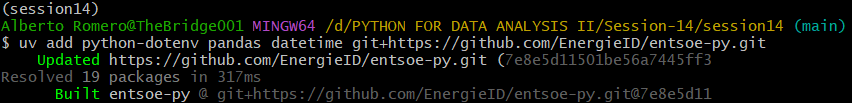



Obtenemos los datos de la **API** a través de **dot-env** para ocultar las claves.

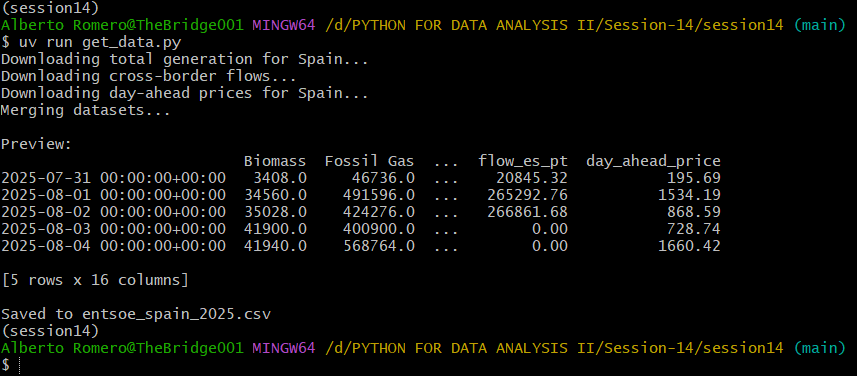

Y ahora comprobamos que podemos ver los datos:

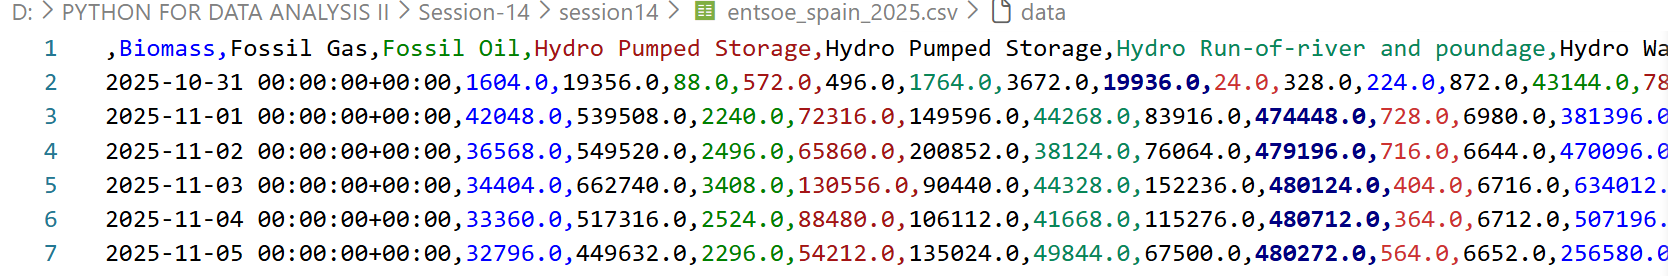

## Pintando los datos

Para limpiar los datos, utilizaremos primero un script (`Energy_visualization.py`) con funciones para trazar gráficos.

```python 

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


def paint_distribution_categorical(df, categorical_columns, relative=False, show_values=False):
    num_columns = len(categorical_columns)
    num_rows = (num_columns // 2) + (num_columns % 2)

    fig, axes = plt.subplots(num_rows, 2, figsize=(15, 5 * num_rows))
    axes = axes.flatten() 

    for i, col in enumerate(categorical_columns):
        ax = axes[i]
        if relative:
            total = df[col].value_counts().sum()
            series = df[col].value_counts().apply(lambda x: x / total)
            sns.barplot(x=series.index, y=series, ax=ax, palette='viridis', hue = series.index, legend = False)
            ax.set_ylabel('Relative Frequency')
        else:
            series = df[col].value_counts()
            sns.barplot(x=series.index, y=series, ax=ax, palette='viridis', hue = series.index, legend = False)
            ax.set_ylabel('Frequency')

        ax.set_title(f'Distribution of {col}')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45)

        if show_values:
            for p in ax.patches:
                height = p.get_height()
                ax.annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2., height), 
                            ha='center', va='center', xytext=(0, 9), textcoords='offset points')

    for j in range(i + 1, num_rows * 2):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()



def plot_categorical_relationship_end(df, cat_col1, cat_col2, relative_freq=False, show_values=False, size_group = 5):
    # Prepare the data
    count_data = df.groupby([cat_col1, cat_col2]).size().reset_index(name='count')
    total_counts = df[cat_col1].value_counts()
    
    # Convert to relative frequencies if requested
    if relative_freq:
        count_data['count'] = count_data.apply(lambda x: x['count'] / total_counts[x[cat_col1]], axis=1)

    # If there are more than size_group categories in cat_col1, divide them into groups of size_group.
    unique_categories = df[cat_col1].unique()
    if len(unique_categories) > size_group:
        num_plots = int(np.ceil(len(unique_categories) / size_group))

        for i in range(num_plots):
            # Select a subset of categories for each chart
            categories_subset = unique_categories[i * size_group:(i + 1) * size_group]
            data_subset = count_data[count_data[cat_col1].isin(categories_subset)]

            # Create the graph
            plt.figure(figsize=(10, 6))
            ax = sns.barplot(x=cat_col1, y='count', hue=cat_col2, data=data_subset, order=categories_subset)

            # Add titles and labels
            plt.title(f'Relationship between {cat_col1} and {cat_col2} - Group {i + 1}')
            plt.xlabel(cat_col1)
            plt.ylabel('Frequency' if relative_freq else 'Count')
            plt.xticks(rotation=45)

            # Display values on the chart
            if show_values:
                for p in ax.patches:
                    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                                ha='center', va='center', fontsize=10, color='black', xytext=(0, size_group),
                                textcoords='offset points')

            # Display the graph
            plt.show()
    else:
        # Create the chart for fewer than size_group categories
        plt.figure(figsize=(10, 6))
        ax = sns.barplot(x=cat_col1, y='count', hue=cat_col2, data=count_data)

        # Add titles and labels
        plt.title(f'Relationship between {cat_col1} and {cat_col2}')
        plt.xlabel(cat_col1)
        plt.ylabel('Frequency' if relative_freq else 'Count')
        plt.xticks(rotation=45)

        # Display values on the chart
        if show_values:
            for p in ax.patches:
                ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='center', fontsize=10, color='black', xytext=(0, size_group),
                            textcoords='offset points')

        # Display the graph
        plt.show()



def plot_categorical_numerical_relationship(df, categorical_col, numerical_col, show_values=False, measure='mean'):
    # Calculate the measure of central tendency (mean or median).
    if measure == 'median':
        grouped_data = df.groupby(categorical_col)[numerical_col].median()
    else:
        # By default, use the average
        grouped_data = df.groupby(categorical_col)[numerical_col].mean()

    # Sort the values
    grouped_data = grouped_data.sort_values(ascending=False)

    # If there are more than 5 categories, divide them into groups of 5.
    if grouped_data.shape[0] > 5:
        unique_categories = grouped_data.index.unique()
        num_plots = int(np.ceil(len(unique_categories) / 5))

        for i in range(num_plots):
            # Select a subset of categories for each chart
            categories_subset = unique_categories[i * 5:(i + 1) * 5]
            data_subset = grouped_data.loc[categories_subset]

            # Create the graph
            plt.figure(figsize=(10, 6))
            ax = sns.barplot(x=data_subset.index, y=data_subset.values)

            # Add titles and labels
            plt.title(f'Relationship between {categorical_col} and {numerical_col} - Group {i + 1}')
            plt.xlabel(categorical_col)
            plt.ylabel(f'{measure.capitalize()} of {numerical_col}')
            plt.xticks(rotation=45)

            # Display values on the chart
            if show_values:
                for p in ax.patches:
                    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                                textcoords='offset points')

            # Display the graph
            plt.show()
    else:
        # Create the chart for fewer than 5 categories
        plt.figure(figsize=(10, 6))
        ax = sns.barplot(x=grouped_data.index, y=grouped_data.values)

        # Add titles and labels
        plt.title(f'Relationship between {categorical_col} and {numerical_col}')
        plt.xlabel(categorical_col)
        plt.ylabel(f'{measure.capitalize()} of {numerical_col}')
        plt.xticks(rotation=45)

        # Display values on the chart
        if show_values:
            for p in ax.patches:
                ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                            textcoords='offset points')

        # Display the graph
        plt.show()


def plot_combined_graphs(df, columns, whisker_width=1.5, bins = None):
    num_cols = len(columns)
    if num_cols:
        
        fig, axes = plt.subplots(num_cols, 2, figsize=(12, 5 * num_cols))
        print(axes.shape)

        for i, column in enumerate(columns):
            if df[column].dtype in ['int64', 'float64']:
                # Histogram and KDE
                sns.histplot(df[column], kde=True, ax=axes[i,0] if num_cols > 1 else axes[0], bins= "auto" if not bins else bins)
                if num_cols > 1:
                    axes[i,0].set_title(f'Histogram and KDE of {column}')
                else:
                    axes[0].set_title(f'Histogram and KDE of {column}')

                # Boxplot
                sns.boxplot(x=df[column], ax=axes[i,1] if num_cols > 1 else axes[1], whis=whisker_width)
                if num_cols > 1:
                    axes[i,1].set_title(f'Boxplot of {column}')
                else:
                    axes[1].set_title(f'Boxplot of {column}')

        plt.tight_layout()
        plt.show()

def plot_grouped_boxplots(df, cat_col, num_col):
    unique_cats = df[cat_col].unique()
    num_cats = len(unique_cats)
    group_size = 5

    for i in range(0, num_cats, group_size):
        subset_cats = unique_cats[i:i+group_size]
        subset_df = df[df[cat_col].isin(subset_cats)]
        
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=cat_col, y=num_col, data=subset_df)
        plt.title(f'Boxplots of {num_col} for {cat_col} (Group {i//group_size + 1})')
        plt.xticks(rotation=45)
        plt.show()



def plot_grouped_histograms(df, cat_col, num_col, group_size):
    unique_cats = df[cat_col].unique()
    num_cats = len(unique_cats)

    for i in range(0, num_cats, group_size):
        subset_cats = unique_cats[i:i+group_size]
        subset_df = df[df[cat_col].isin(subset_cats)]
        
        plt.figure(figsize=(10, 6))
        for cat in subset_cats:
            sns.histplot(subset_df[subset_df[cat_col] == cat][num_col], kde=True, label=str(cat))
        
        plt.title(f'Histograms of {num_col} for {cat_col} (Group {i//group_size + 1})')
        plt.xlabel(num_col)
        plt.ylabel('Frequency')
        plt.legend()
        plt.show()

####

def graph_dispersion_with_correlation(df, column_x, column_y, point_size=50, show_correlation=False):
    """
    Creates a scatter plot between two columns and optionally displays the correlation.

    Args:
    df (pandas.DataFrame): DataFrame containing the data.
    column_x (str): Name of the column for the X axis.
    column_y (str): Name of the column for the Y axis.
    dot_size (int, optional): Size of the dots in the graph. The default is 50.
    show_correlation (bool, optional): If True, show the correlation in the graph. The default is False.
    """

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x=column_x, y=column_y, s=point_size)

    if show_correlation:
        correlation = df[[column_x, column_y]].corr().iloc[0, 1]
        plt.title(f'Scatter Plot with Correlation: {correlation:.2f}')
    else:
        plt.title('Scatter Diagram')

    plt.xlabel(column_x)
    plt.ylabel(column_y)
    plt.grid(True)
    plt.show()


def bubble_plot(df, col_x, col_y, col_size, scale = 1000):
    """
    Create a scatter plot using two columns for the X and Y axes,
    and a third column to determine the size of the points.

    Args:
    df (pd.DataFrame): Pandas DataFrame.
    col_x (str): Name of the column for the X axis.
    col_y (str): Name of the column for the Y axis.
    col_size (str): Name of the column to determine the size of the points.
    """

    # Ensure that the size values are positive.
    sizes = (df[col_size] - df[col_size].min() + 1)/scale

    plt.scatter(df[col_x], df[col_y], s=sizes)
    plt.xlabel(col_x)
    plt.ylabel(col_y)
    plt.title(f'Bubbles of {col_x} vs {col_y} with Size based on {col_size}')
    plt.show()




```

## Limpieza de datos

Además, utilizaremos el cuaderno `02_Cleaning_data.ipynb` para limpiar los datos que hemos obtenido con el script del punto anterior.

Veamos el cuaderno.

## Entrenamiento, validación y prueba. ¡Usemos el aprendizaje automático!

Ahora utilizaremos el cuaderno `03_Train_Evaluation.ipynb` para aplicar el aprendizaje automático y crear un modelo que permita realizar predicciones sobre el precio de la energía.

Veamos el cuaderno.


## La aplicación de Streamlit

Veamos la aplicación de Streamlit:

```python
import streamlit as st
import pickle
import numpy as np

st.title('Energy forecaster')

# Model load
with open("models/model_lgb.pkl", "rb") as f:
    model = pickle.load(f)

# Create tabs
tab1, tab2 = st.tabs(["Prediction", "About the model"])

with tab1:
    text_1 = """
<p style="text-align: justify;">
The price of electricity varies continuously depending on the energy mix available at any given time. 
Each type of generation contributes differently to the final market cost. 
\n In this tool, you can simulate the amount generated in a day in each of the six most influential sources using the sliders, and the predictive model will estimate
the price of electricity in €/MWh according to the chosen combination.
</p>
"""
    st.markdown(text_1, unsafe_allow_html=True)
    st.header("Enter the generation in one day (MWh)")

    col1, col2, col3 = st.columns([6, 6, 6])
    
    #	Fossil Gas	Hydro Pumped Storage.1	Nuclear	Waste	Fossil Oil	Fossil Hard coal
    
    with col1:
        fossil_gas = st.slider("Fossil Gas", 2_000.0, 15_300.0,  5_000.0, 10.0)
        hydro = st.slider("Hydro Pumped Storage.1", 36.0, 2_950.0, 1_050.0, 10.0)
        nuclear = st.slider("Nuclear", 11.0, 7_150.0, 6_000.0, 10.0)
            
    with col2:       
        waste = st.slider("Waste", 96.0, 310.0, 195.0, 10.0)
        fossil_oil = st.slider("Fossil Oil", 2.0, 92.0, 31.0, 10.0)
        fossil_hard_coal = st.slider("Fossil Hard coal", 0.0, 920.0, 290.0, 10.0)

    with col3:
        if st.button("Predict price €/MWh"):
            input_data = np.array([[fossil_gas, fossil_hard_coal, fossil_oil, hydro, nuclear, waste]])
            pred = model.predict(input_data)
            st.metric("Estimated price (€/MWh))", f"{pred[0]:.2f}")
    text_2 = """
    <p style="text-align: justify;">
    For the predictor to work best, the default value for each slider corresponds to the average daily generation of each source in the dataset
    used to train the model. 
    The maximum and minimum values correspond to the maximum and minimum generation recorded in a day for each source.
    </p>
    """            
    st.markdown(text_2, unsafe_allow_html=True)

with tab2:
    st.header("Project objective")

    text_3 = """
    <p style="text-align: justify;">
    The purpose of this project is to develop a regression model based on machine learning techniques that allows the 
    daily price of electricity to be estimated based on the available energy mix. This model was trained using historical data that
    includes:<br><br>
    - The contribution of each technology to the daily energy mix.<br>
    - Resulting price in the wholesale market.<br><br>
    The ultimate goal is to build a model capable of anticipating price behaviour, facilitating strategic decision-making
    and improving operational management within the market.
    </p>
    """
    st.markdown(text_3, unsafe_allow_html=True)

    st.header("Data used")
    text_4 = """
    <p style="text-align: justify;">
    The data used in this project comes from official sources. Specifically, from Red Eléctrica de España. The data has been downloaded from
    the REE API, which provides detailed information on electricity generation by source, demand and prices.
    Daily data has been collected to ensure adequate
    representativeness of the model.<br><br>   
    """
    st.markdown(text_4, unsafe_allow_html=True)

    st.header("About the model")
    text_5 = """
    <div style="line-height:1.4;">
      <p style="text-align: justify; margin-bottom: 0.6rem;">
        A Random Forest Regressor model was used to construct the predictor, selected for its ability to capture non-linear relationships and its good performance in complex prediction problems.
        The model was evaluated on a test set of 20% of the data, obtaining the following metrics: 
        The model was evaluated on a test set comprising 20% of the data, obtaining the following metrics:
      </p>

      <p style="text-align: justify; margin-top:0.2rem;">
        The main metrics are: 
        <span style="text-decoration: underline; font-weight:600;">R²</span>, 
        <span style="text-decoration: underline; font-weight:600;">MAE</span>, 
        <span style="text-decoration: underline; font-weight:600;">RMSE</span> y 
        <span style="text-decoration: underline; font-weight:600;">MAPE</span>.
      </p>

      <div style="margin-top:1rem; display:flex; justify-content:center;">
        <table style="border-collapse: collapse; width: 340px;">
          <thead>
            <tr>
              <th style="text-align: left; padding: 6px 10px; border-bottom: 2px solid #ddd;">Metric</th>
              <th style="text-align: right; padding: 6px 10px; border-bottom: 2px solid #ddd;">Value</th>
            </tr>
          </thead>
          <tbody>
            <tr>
              <td style="padding: 6px 10px; border-bottom: 1px solid #f0f0f0;">R²</td>
              <td style="padding: 6px 10px; text-align: right; border-bottom: 1px solid #f0f0f0;">0.8657</td>
            </tr>
            <tr>
              <td style="padding: 6px 10px; border-bottom: 1px solid #f0f0f0;">MAE (€/MWh)</td>
              <td style="padding: 6px 10px; text-align: right; border-bottom: 1px solid #f0f0f0;">10.0763</td>
            </tr>
            <tr>
              <td style="padding: 6px 10px; border-bottom: 1px solid #f0f0f0;">RMSE (€/MWh)</td>
              <td style="padding: 6px 10px; text-align: right; border-bottom: 1px solid #f0f0f0;">14.1760</td>
            </tr>
            <tr>
              <td style="padding: 6px 10px;">MAPE</td>
              <td style="padding: 6px 10px; text-align: right;">27.5855%</td>
            </tr>
          </tbody>
        </table>
      </div>
    </div>
    """

    st.markdown(text_5, unsafe_allow_html=True)

```

Y podemos ejecutar el script:

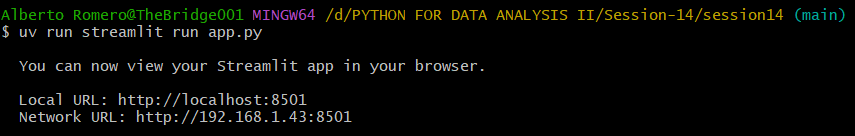

## ¡Servimos la aplicación de Streamlit!

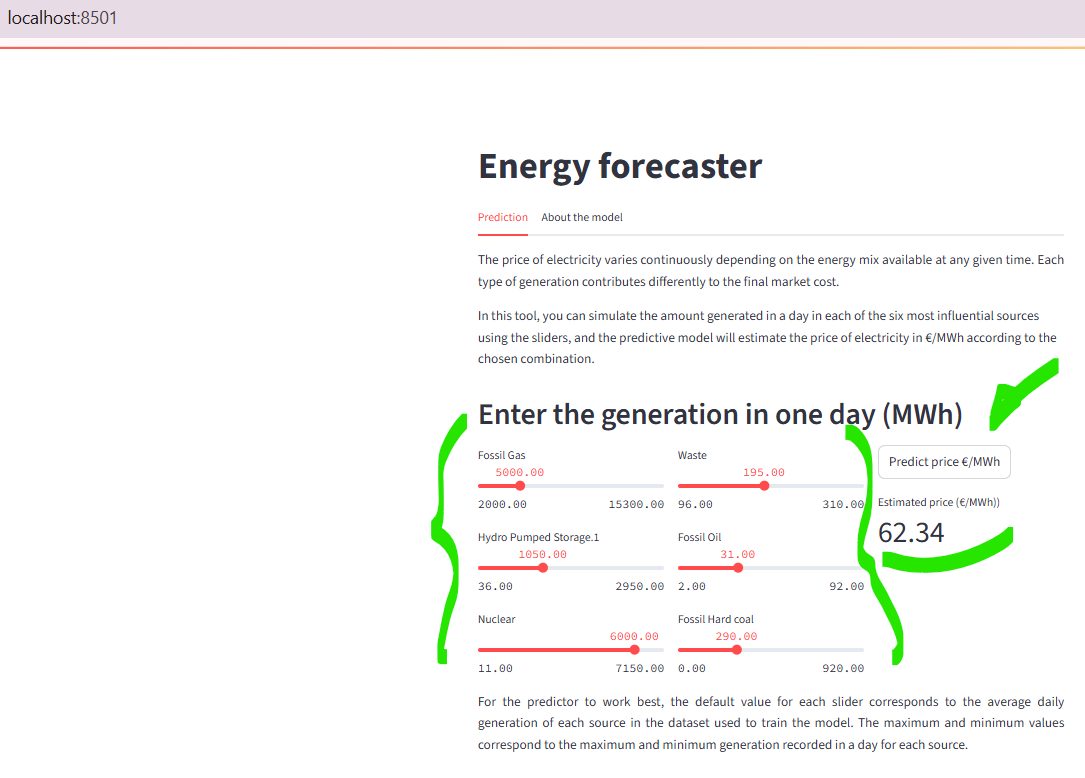

Si haces clic en el botón «predict», podrás hacer predicciones sobre el precio de la energía.



Por cierto, hemos conseguido unos resultados bastante buenos.

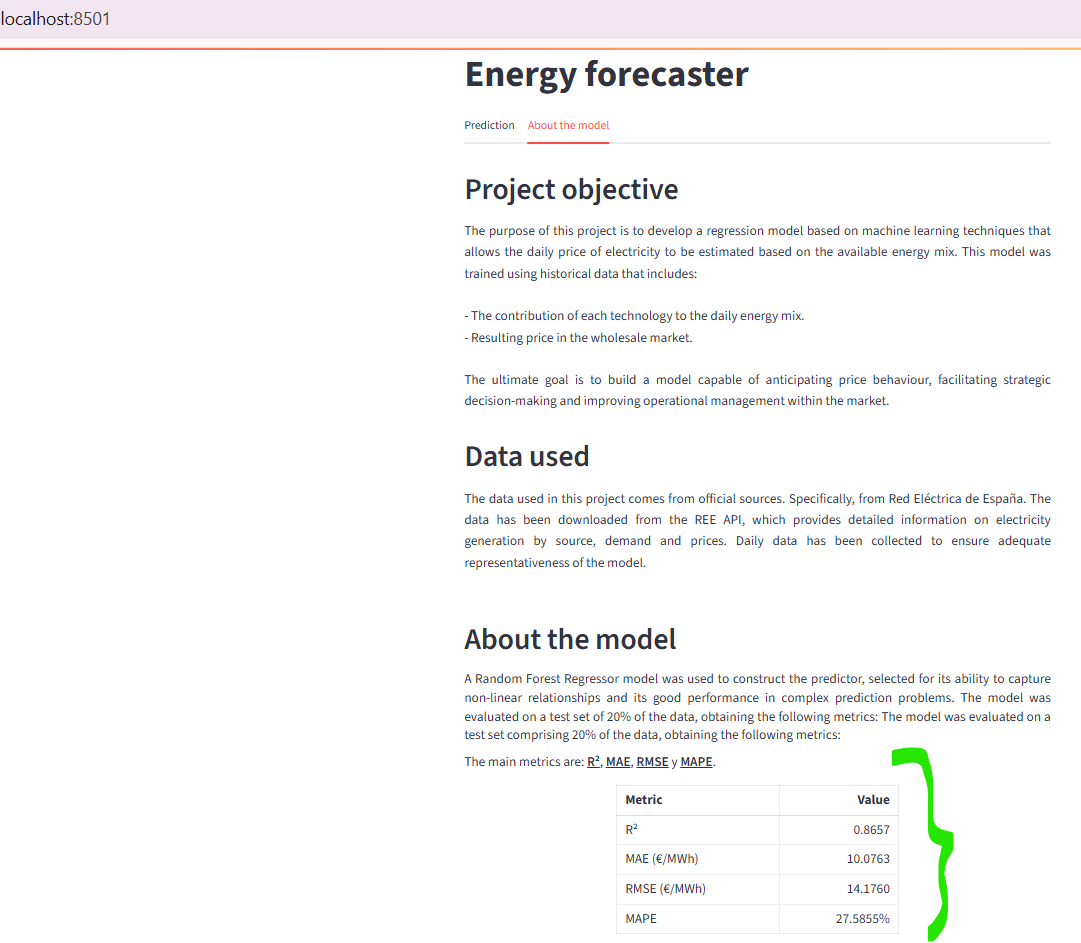